# CIFAR-10 kuvien luokittelu CNN-mallilla

Tässä työssä toteutetaan konvoluutioneuroverkko, jolla luokitellaan CIFAR-10-datasetin kuvia. Tavoitteena on opettaa malli tunnistamaan 10 eri luokkaa värikuvista ja arvioida sen suorituskykyä.

## Importit

Tässä tuodaan tarvittavat kirjastot neuroverkon rakentamiseen, datan käsittelyyn ja tulosten visualisointiin.

In [12]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers
import numpy as np
import matplotlib.pyplot as plt

## Datan lataus

Ladataan CIFAR-10 dataset, joka sisältää 50 000 koulutuskuvaa ja 10 000 testikuvaa. Jokainen kuva on kooltaan 32x32 ja sisältää 3 värikanavaa (RGB).

In [2]:
# Ladataan CIFAR-10 data
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


c:\Users\quang\anaconda3\envs\keras\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


## Datan esikäsittely

Normalisoidaan kuvien pikseliarvot välille [0,1], jotta mallin oppiminen on tehokkaampaa. Lisäksi muunnetaan luokat one-hot -muotoon, jotta ne sopivat neuroverkon ulostuloon.

In [3]:
# Normalisoidaan pikseliarvot välille [0,1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

## CNN-mallin määrittely

Rakennetaan konvoluutioneuroverkko, joka koostuu konvoluutiokerroksista, pooling-kerroksista ja täysin yhdistetyistä kerroksista. Malli oppii tunnistamaan kuvista piirteitä ja luokittelemaan ne oikeaan luokkaan.

In [4]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

inputs = keras.Input(shape=(32, 32, 3))

x = data_augmentation(inputs)

# Lohko 1: konvoluutio + normalisointi + alasnäytteistys
x = layers.Conv2D(32, (3,3), padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(32, (3,3), padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Dropout(0.3)(x)

# Lohko 2: syvemmät piirteet suuremmalla suodatinmäärällä
x = layers.Conv2D(64, (3,3), padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(64, (3,3), padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Dropout(0.3)(x)

# Lohko 3: vielä abstraktimmat piirteet
x = layers.Conv2D(128, (3,3), padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(128, (3,3), padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Dropout(0.3)(x)

# Täysin yhdistetyt kerrokset (luokittelija)
x = layers.Flatten()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)

# Ulostulokerros: 10 luokkaa (softmax antaa todennäköisyydet)
outputs = layers.Dense(10, activation="softmax")(x)

# Mallin muodostus
model = keras.Model(inputs, outputs)

# Tulostetaan mallin rakenne
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,54

 Total params: 816,938 (3.12 MB)

 Trainable params: 815,530 (3.11 MB)

 Non-trainable params: 1,408 (5.50 KB)

## Mallin kääntäminen

Määritellään optimointimenetelmä ja häviöfunktio.

In [5]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

## Mallin koulutus

Koulutetaan malli ja seurataan sen oppimista validointidatan avulla.

In [6]:
callback = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    x_train, y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.2,
    callbacks=[callback]
)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 95s 285ms/step - accuracy: 0.3257 - loss: 2.1273 - val_accuracy: 0.1189 - val_loss: 4.8529
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 85s 273ms/step - accuracy: 0.4347 - loss: 1.6087 - val_accuracy: 0.4671 - val_loss: 1.5486
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 85s 272ms/step - accuracy: 0.4994 - loss: 1.4044 - val_accuracy: 0.4960 - val_loss: 1.4699
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 85s 272ms/step - accuracy: 0.5404 - loss: 1.2868 - val_accuracy: 0.5159 - val_loss: 1.4254
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 86s 276ms/step - accuracy: 0.5714 - loss: 1.2038 - val_accuracy: 0.6114 - val_loss: 1.1307
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 87s 277ms/step - accuracy: 0.5952 - loss: 1.1365 - val_accuracy: 0.5753 - val_loss: 1.3613
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 85s 272ms/step - accuracy: 0.6163 - loss: 1.0796 - val_accuracy: 0.5806 - val_loss: 1.2474
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 522s 2s/step - accuracy: 0.6313 - loss: 1.0

## Mallin evaluointi

Testataan mallin tarkkuus testidatalla.

In [7]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7397 - loss: 0.7669
Test loss: 0.76685631275177
Test accuracy: 0.7397000193595886


## Oppimiskäyrät

Visualisoidaan training ja validation loss.

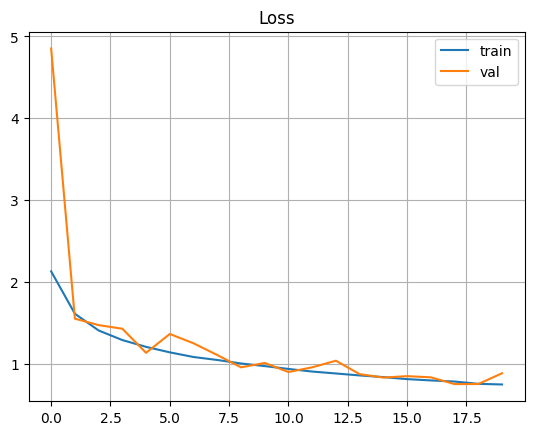

In [8]:
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.legend()
plt.title("Loss")
plt.grid()
plt.show()

## Ennusteiden visualisointi

Näytetään mallin ennusteita testikuville.

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step


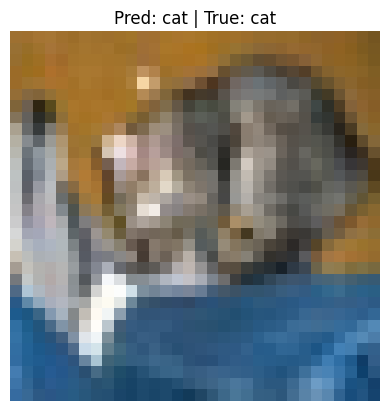

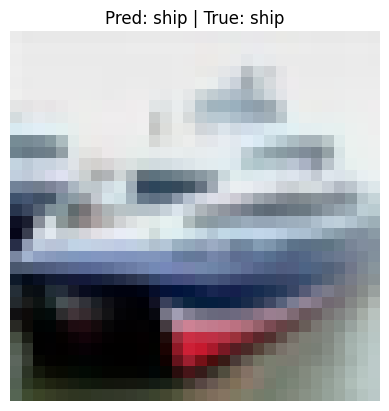

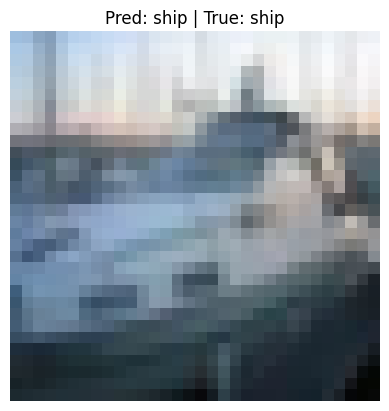

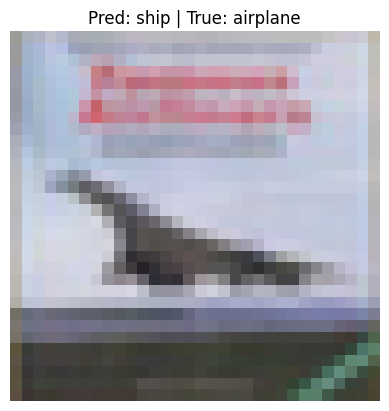

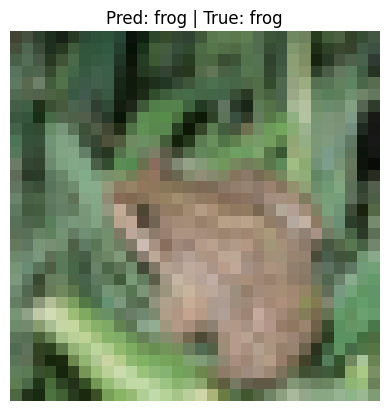

In [9]:
class_names = ["airplane","automobile","bird","cat","deer",
               "dog","frog","horse","ship","truck"]

predictions = model.predict(x_test)

for i in range(5):
    plt.imshow(x_test[i])
    pred = np.argmax(predictions[i])
    true = np.argmax(y_test[i])
    plt.title(f"Pred: {class_names[pred]} | True: {class_names[true]}")
    plt.axis("off")
    plt.show()

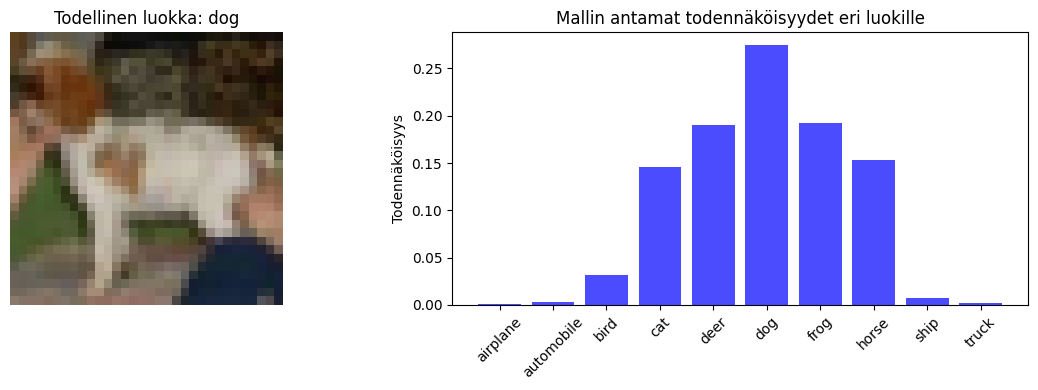

In [10]:
# Valitaan yksi kuva testidatasta (esim. indeksi 12)
index = 12
kuva = x_test[index]
todennakoisyydet = predictions[index]

# Piirretään kuva ja todennäköisyydet vierekkäin
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Vasen puoli: Kuva
ax1.imshow(kuva)
ax1.axis("off")
todellinen_luokka = class_names[np.argmax(y_test[index])]
ax1.set_title(f"Todellinen luokka: {todellinen_luokka}")

# Oikea puoli: Pylväskaavio todennäköisyyksistä
y_pos = np.arange(len(class_names))
ax2.bar(y_pos, todennakoisyydet, align='center', color='blue', alpha=0.7)
ax2.set_xticks(y_pos)
ax2.set_xticklabels(class_names, rotation=45)
ax2.set_ylabel('Todennäköisyys')
ax2.set_title('Mallin antamat todennäköisyydet eri luokille')

plt.tight_layout()
plt.show()

## Väärin luokitellut kuvat

Tarkastellaan mallin tekemiä virheitä.

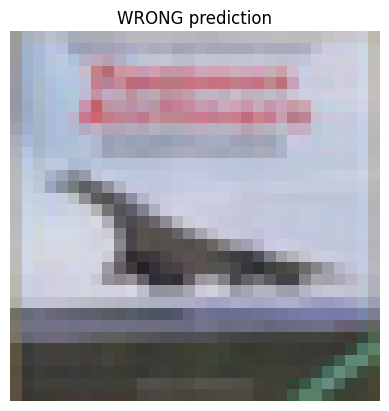

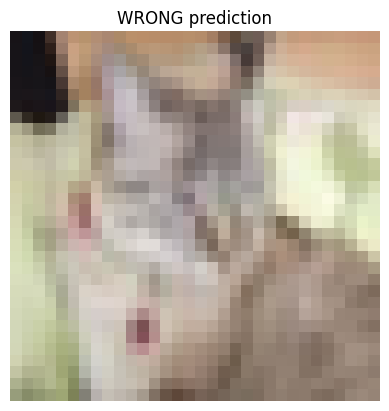

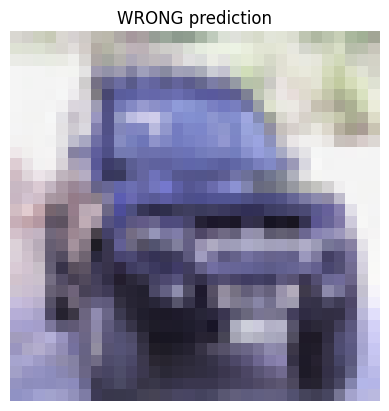

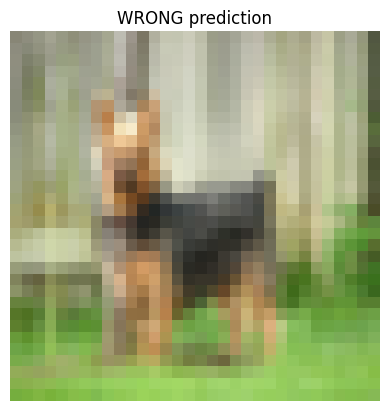

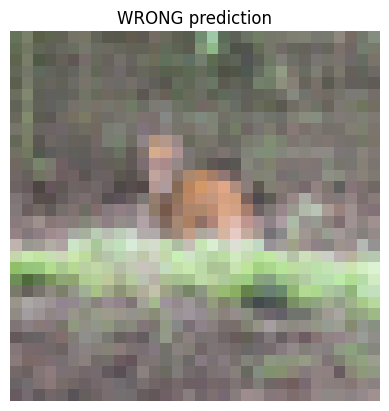

In [11]:
wrong = np.where(
    np.argmax(predictions, axis=1) != np.argmax(y_test, axis=1)
)[0]

for i in wrong[:5]:
    plt.imshow(x_test[i])
    plt.title("WRONG prediction")
    plt.axis("off")
    plt.show()